<a href="https://colab.research.google.com/github/udayjadhav-uj/OIBSIP/blob/main/Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 Rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       

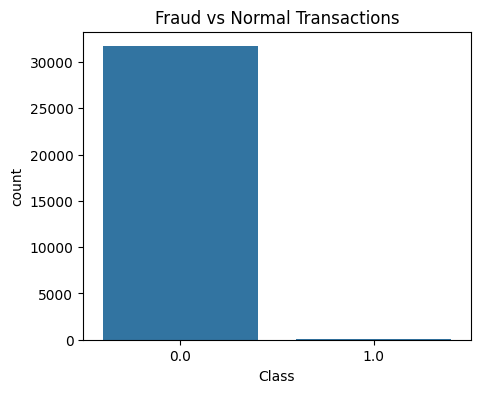


Logistic Regression Accuracy:
0.9973253618628068

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      6332
         1.0       0.67      0.58      0.62        24

    accuracy                           1.00      6356
   macro avg       0.83      0.79      0.81      6356
weighted avg       1.00      1.00      1.00      6356


Decision Tree Accuracy:
0.999056010069226

Classification Report (Decision Tree):
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      6332
         1.0       0.85      0.92      0.88        24

    accuracy                           1.00      6356
   macro avg       0.92      0.96      0.94      6356
weighted avg       1.00      1.00      1.00      6356



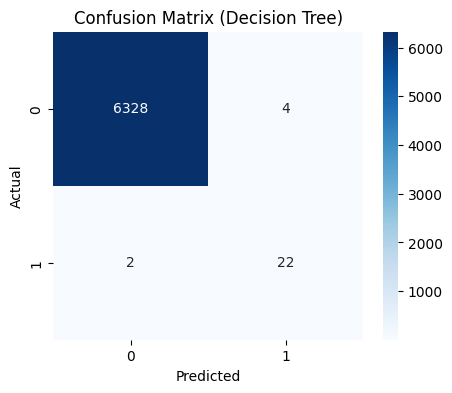


Fraud Transactions Percentage: 0.320966676106863 %


In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Load Dataset
df = pd.read_csv("creditcard.csv")

# Display first rows
print("First 5 Rows:")
print(df.head())

# Dataset info
print("\nDataset Info:")
print(df.info())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Handle missing values by dropping rows with any NaN values
df.dropna(inplace=True)
print("\nDataFrame after dropping NaN values:")
print(df.isnull().sum())

# Fraud vs Normal transactions
print("\nTransaction Class Distribution:")
print(df['Class'].value_counts())

# Visualization of Fraud vs Normal
plt.figure(figsize=(5,4))
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

# Feature Scaling for Amount and Time
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

# Features and Target
X = df.drop('Class', axis=1)
y = df['Class']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Logistic Regression Model
# -----------------------------
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("\nLogistic Regression Accuracy:")
print(accuracy_score(y_test, lr_pred))

print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, lr_pred))

# -----------------------------
# Decision Tree Model
# -----------------------------
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("\nDecision Tree Accuracy:")
print(accuracy_score(y_test, dt_pred))

print("\nClassification Report (Decision Tree):")
print(classification_report(y_test, dt_pred))

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix (Decision Tree)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Fraud Percentage
fraud_percentage = (df['Class'].sum() / len(df)) * 100
print("\nFraud Transactions Percentage:", fraud_percentage, "%")